In [1]:
import pandas as pd
import numpy as np
from FaceQuant import FaceQuantVec
import os
from tqdm import tqdm

In [2]:
måske = [
    # 1A1
    'Airpuff2026-03-14T17_08_19_after5s_first1s', 
    'Airpuff2026-03-14T17_14_19_after5s_first1s', 
    'Airpuff2026-03-14T17_08_19_after5s_first1s',
    'Airpuff2026-03-14T17_14_19_after5s_first1s',
    'Airpuff2026-03-19T17_51_58_after5s_first1s',
    'Airpuff2026-03-19T17_51_58_after5s_first1s',
    'Airpuff2026-03-19T17_53_58_after5s_first1s',
    'Airpuff2026-03-19T17_55_58_after5s_first1s',
    'Airpuff2026-03-26T17_40_42_after5s_first1s',
    'Airpuff2026-04-02T18_58_42_after5s_first1s',
    'Sucrose2026-03-19T17_23_55_after5s_first1s',
    'Sucrose2026-03-19T17_27_55_after5s_first1s',
    'Sucrose2026-03-23T16_28_02_after5s_first1s',
    # 1A4
    'Airpuff2026-03-12T22_53_04_after5s_first1s',
    'Airpuff2026-03-23T16_06_31_after5s_first1s',
    'Airpuff2026-03-23T16_08_31_after5s_first1s',
    'Airpuff2026-03-23T16_06_31_after5s_first1s',
    'Airpuff2026-03-23T16_08_31_after5s_first1s',
    'Airpuff2026-03-30T15_57_47_after5s_first1s',
    # 1A11
    'Airpuff2026-03-14T17_53_44_after5s_first1s',
    'Airpuff2026-03-26T18_26_50_after5s_first1s',
    #4B1
    'Airpuff2026-03-14T13_52_19_after5s_first1s',
    'Airpuff2026-03-16T13_40_57_after5s_first1s',
    'Airpuff2026-03-16T13_46_57_after5s_first1s',
    'Airpuff2026-03-19T13_04_34_after5s_first1s',
    'Airpuff2026-03-19T13_10_35_after5s_first1s',
    #4B4
    'Airpuff2026-03-26T13_32_06_after5s_first1s',
    'Quinine2026-03-26T13_18_31_after5s_first2s',
    'Quinine2026-03-26T13_20_31_after5s_first2s',
    'Sucrose2026-04-03T08_37_23_after5s_first1s',
    #7C
    #10B3
    'Airpuff2026-03-12T18_30_59_after5s_first1s',
    'Quinine2026-04-02T12_02_24_after5s_first2s',
    'Sucrose2026-03-12T18_08_47_after5s_first1s',
    'Sucrose2026-03-19T11_39_02_after5s_first1s',
    #10B4
    'Airpuff2026-03-12T17_50_06_after5s_first1s',
    'Sucrose2026-03-23T10_33_45_after5s_first1s',

    ]

nope = [
    # 1A1
    'Airpuff2026-03-14T17_10_19_after5s_first1s', 
    'Airpuff2026-03-14T17_10_19_after5s_first1s',
    'Airpuff2026-03-19T17_55_58_after5s_first1s',
    # 1A4
    # 1A11
    'Airpuff2026-03-14T17_51_44_after5s_first1s',
    'Sucrose2026-03-16T17_30_33_after5s_first1s',
    'Sucrose2026-03-16T17_32_33_after5s_first1s',
    'Sucrose2026-03-16T17_34_33_after5s_first1s',
    'Sucrose2026-03-16T17_36_33_after5s_first1s',
    #4B1
    'Airpuff2026-03-14T13_54_19_after5s_first1s',
    'Sucrose2026-03-26T12_35_53_after5s_first1s',
    #4B4
    'Airpuff2026-03-14T14_33_17_after5s_first1s',
    'Airpuff2026-03-23T13_54_51_after5s_first1s',
    'Airpuff2026-03-26T13_34_06_after5s_first1s',
    #7C
    'Airpuff2026-03-12T22_02_28_after5s_first1s',
    'Airpuff2026-03-19T16_06_02_after5s_first1s',
    'Airpuff2026-03-30T14_12_20_after5s_first1s',
    #10B3
    'Airpuff2026-03-14T12_24_17_after5s_first1s',
    'Sucrose2026-03-14T11_52_36_after5s_first1s',
    #10B4
    'Airpuff2026-03-16T11_13_38_after5s_first1s',
    'Quinine2026-03-23T10_44_18_after5s_first2s',
    'Sucrose2026-03-30T10_42_12_after5s_first1s',
    ]

In [3]:
len('Airpuff2026-03-14T14_33_17_after5s_first1s')

42

## Load data

In [4]:
import os

csv_files = []

for root, dirs, files in os.walk('C2shortvideosDLCanalyzed_reanalyzed_v2/'):
    for f in files:
        #if f.endswith('.csv') and f[:42] not in nope:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))



In [5]:
len(csv_files)

719

In [6]:
all_results = []

ill_dict = {
    '7C':'TDP43',
    '10B3':'TDP43',
    '1A1':'TDP43',
    '1A11':'TDP43',
    '10B4':'WT',
    '1A4':'WT',
    '4B1':'WT',
    '4B4':'WT',
    }

for csv_file in tqdm(csv_files):
    df = pd.read_csv(csv_file, header=[1, 2])
    df.columns.names = ["scorer", "bodyparts"]
    n = len(df)

    if n > 200:
        fq = FaceQuantVec(df)
        quant_df = fq.compute()

        quant_df["group"] = ill_dict[csv_file.split('\\')[1]]

        if '_' not in csv_file.split('\\')[2]:
            phase = 'Preinduction'
        elif  csv_file.split('\\')[2].split('_')[1] == 'W1':
            phase = '1st week'
        elif  csv_file.split('\\')[2].split('_')[1] == 'W2':
            phase = '2nd week'

        quant_df["phase"] = phase 
        quant_df["file"] = csv_file 

        if "Airpuff" in csv_file:
            quant_df["stimuli"] = ["neutral"] * 200 + ["airpuf"] * (n - 200)
        elif "quinine" in csv_file:
            quant_df["stimuli"] = ["neutral"] * 200 + ["quinine"] * (n - 200)
        elif "Sucrose" in csv_file:
            quant_df["stimuli"] = ["neutral"] * 200 + ["sucrose"] * (n - 200)
    
        all_results.append(quant_df)

fq_df = pd.concat(all_results, ignore_index=True)


100%|██████████| 719/719 [00:17<00:00, 39.98it/s]


In [7]:
fq_df

,eye_opening,ear_opening,ear_position,snout_position,mouth_position,face_inclination,group,phase,file,stimuli
0,0.650458,0.638794,56.218502,111.868633,31.340696,52.482434,TDP43,Preinduction,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral
1,0.642352,0.628075,57.826554,110.415325,31.177547,52.061736,TDP43,Preinduction,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral
2,0.643555,0.634568,57.757005,109.334840,30.933426,51.878159,TDP43,Preinduction,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral
3,0.644078,0.628943,58.300153,109.317538,30.982729,52.016799,TDP43,Preinduction,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral
4,0.637023,0.634744,58.526406,104.776060,30.771055,51.547047,TDP43,Preinduction,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral
...,...,...,...,...,...,...,...,...,...,...
271195,0.677870,0.718721,55.039069,107.220334,26.554911,51.638527,TDP43,2nd week,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose
271196,0.669032,0.732412,54.985698,104.501696,25.649920,51.382426,TDP43,2nd week,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose
271197,0.673710,0.733246,55.126888,103.732073,25.445992,51.969985,TDP43,2nd week,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose
271198,0.675346,0.736520,54.660284,103.197969,25.105905,51.797137,TDP43,2nd week,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose


In [8]:
fq_df_filter = fq_df[(fq_df['eye_opening'] < 1) & (fq_df['ear_opening'] < 1)]

In [9]:
from scipy.stats import zscore

quant_cols = [
    "eye_opening",
    "ear_opening",
    "ear_position",
    "snout_position",
    "mouth_position",
    "face_inclination"
]

fq_df[quant_cols] = fq_df[quant_cols].apply(zscore)
import numpy as np

mean_df = fq_df.groupby("stimuli")[quant_cols].mean()
sem_df  = fq_df.groupby("stimuli")[quant_cols].sem()



In [10]:
c_group = []
for i, row in fq_df.iterrows():
    if row['group'] == 'TDP43' and row['phase'] == 'WT':
        c_group.append('control')
    else:
        c_group.append(row['group'])

fq_df['c_group'] = c_group

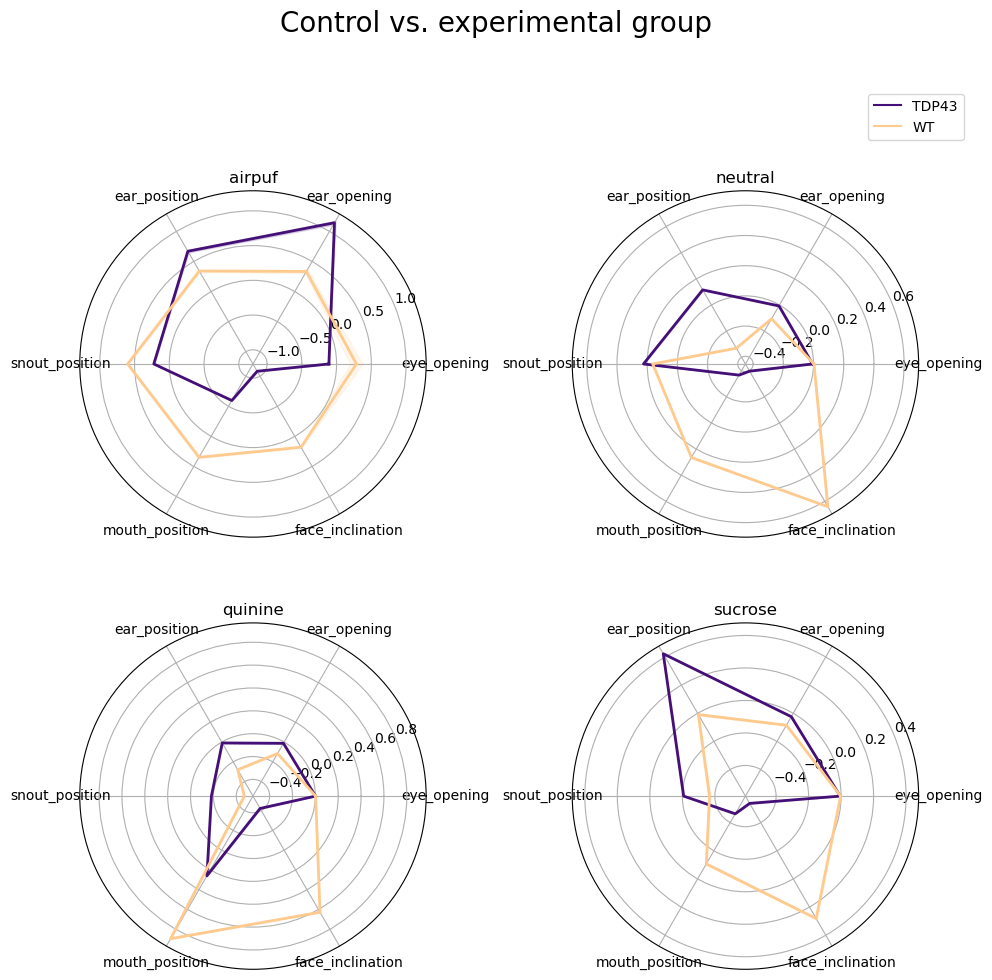

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import math

labels = quant_cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

stimuli = sorted(fq_df["stimuli"].unique())
groups = sorted(fq_df["group"].unique())

# Explicit colors per group
group_colors = {
    "TDP43": "#440f76",
    "WT": "#feca8d",
}

cols = 2
rows = math.ceil(len(stimuli) / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 5, rows * 5),
    subplot_kw=dict(polar=True)
)

axes = axes.flatten()

for ax, stim in zip(axes, stimuli):

    stim_df = fq_df[fq_df["stimuli"] == stim]

    stim_mean = stim_df.groupby("group")[quant_cols].mean()
    stim_sem  = stim_df.groupby("group")[quant_cols].sem()

    for group in groups:
        if group not in stim_mean.index:
            continue

        values = stim_mean.loc[group].tolist()
        values += values[:1]

        sem = stim_sem.loc[group].tolist()
        sem += sem[:1]

        lower = np.array(values) - np.array(sem)
        upper = np.array(values) + np.array(sem)

        color = group_colors.get(group, "gray")

        ax.plot(angles, values, linewidth=2, label=group, color=color)
        ax.fill_between(angles, lower, upper, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(stim)

# Hide unused axes
for ax in axes[len(stimuli):]:
    ax.set_visible(False)

# Global legend with correct colors
handles = []
labels_legend = []

for group in groups:
    color = group_colors.get(group, "gray")
    h, = axes[0].plot([], [], label=group, color=color)
    handles.append(h)
    labels_legend.append(group)

plt.suptitle("Control vs. experimental group", fontsize=20, y=1)
axes[1].legend(
    handles,
    labels_legend,
    loc="upper right",
    bbox_to_anchor=(1.15, 1.3)
)

plt.tight_layout()
plt.savefig("cont_exp.svg")
plt.show()



In [23]:
fq_df

,eye_opening,ear_opening,ear_position,snout_position,mouth_position,face_inclination,group,phase,file,stimuli,c_group
0,-0.009475,-0.083331,0.120521,1.065081,-0.178890,-0.603503,TDP43,Preinduction,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,TDP43
1,-0.015852,-0.099460,0.318336,0.897496,-0.216202,-0.649300,TDP43,Preinduction,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,TDP43
2,-0.014906,-0.089689,0.309780,0.772902,-0.272032,-0.669284,TDP43,Preinduction,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,TDP43
3,-0.014495,-0.098153,0.376596,0.770907,-0.260756,-0.654192,TDP43,Preinduction,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,TDP43
4,-0.020046,-0.089425,0.404428,0.247218,-0.309166,-0.705329,TDP43,Preinduction,C2shortvideosDLCanalyzed_reanalyzed_v2/Airpuff...,neutral,TDP43
...,...,...,...,...,...,...,...,...,...,...,...
271195,0.012093,0.036934,-0.024568,0.529073,-1.273392,-0.695370,TDP43,2nd week,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose,TDP43
271196,0.005140,0.057536,-0.031133,0.215580,-1.480362,-0.723249,TDP43,2nd week,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose,TDP43
271197,0.008820,0.058790,-0.013765,0.126833,-1.527000,-0.659288,TDP43,2nd week,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose,TDP43
271198,0.010107,0.063715,-0.071164,0.065244,-1.604777,-0.678104,TDP43,2nd week,C2shortvideosDLCanalyzed_reanalyzed_v2/Sucrose...,sucrose,TDP43


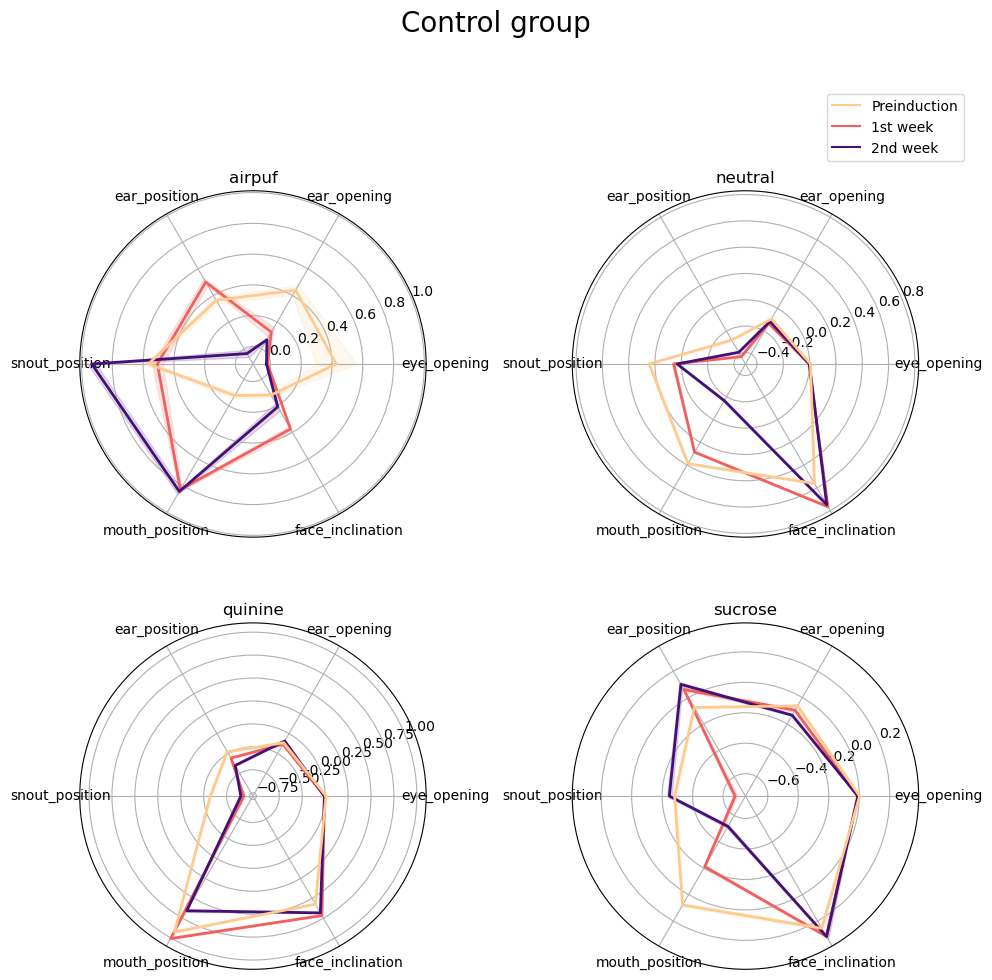

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import math

labels = quant_cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

stimuli = sorted(fq_df["stimuli"].unique())
groups = sorted(fq_df["phase"].unique())

# Explicit colors per group
group_colors = {
    "Preinduction": "#feca8d",
    "1st week": "#f1605d",
    "2nd week": "#440f76",
}

cols = 2
rows = math.ceil(len(stimuli) / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 5, rows * 5),
    subplot_kw=dict(polar=True)
)

axes = axes.flatten()

for ax, stim in zip(axes, stimuli):

    stim_df = fq_df[(fq_df["stimuli"] == stim) & (fq_df["group"] == 'WT')]

    stim_mean = stim_df.groupby("phase")[quant_cols].mean()
    stim_sem  = stim_df.groupby("phase")[quant_cols].sem()

    for group in groups:
        if group not in stim_mean.index:
            continue

        values = stim_mean.loc[group].tolist()
        values += values[:1]

        sem = stim_sem.loc[group].tolist()
        sem += sem[:1]

        lower = np.array(values) - np.array(sem)
        upper = np.array(values) + np.array(sem)

        color = group_colors.get(group, "gray")

        ax.plot(angles, values, linewidth=2, label=group, color=color)
        ax.fill_between(angles, lower, upper, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(stim)

# Hide unused axes
for ax in axes[len(stimuli):]:
    ax.set_visible(False)

legend_order = ["Preinduction", "1st week", "2nd week"]  # your desired order

handles = []
labels_legend = []

for group in legend_order:
    color = group_colors.get(group, "gray")
    h, = axes[0].plot([], [], label=group, color=color)
    handles.append(h)
    labels_legend.append(group)
plt.suptitle("Control group", fontsize=20, y=1)



axes[1].legend(
    handles,
    labels_legend,
    loc="upper right",
    bbox_to_anchor=(1.15, 1.3)
)

plt.tight_layout()
plt.savefig("cont_group.svg")
plt.show()

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import os



labels = quant_cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

stimuli = sorted(fq_df["stimuli"].unique())
groups = sorted(fq_df["phase"].unique())

group_colors = {
    "Preinduction": "#feca8d",
    "1st week": "#f1605d",
    "2nd week": "#440f76",
}

# Create output folder
output_dir = "radar_plots"
os.makedirs(output_dir, exist_ok=True)

legend_order = ["Preinduction", "1st week", "2nd week"]
genotypes = ['WT', 'TDP43']
for genotype in genotypes:
    for stim in stimuli:

        fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

        stim_df = fq_df[
            (fq_df["stimuli"] == stim) &
            (fq_df["group"] == genotype)
        ]

        stim_mean = stim_df.groupby("phase")[quant_cols].mean()
        stim_sem = stim_df.groupby("phase")[quant_cols].sem()

        for group in groups:
            if group not in stim_mean.index:
                continue

            values = stim_mean.loc[group].tolist()
            values += values[:1]

            sem = stim_sem.loc[group].tolist()
            sem += sem[:1]

            lower = np.array(values) - np.array(sem)
            upper = np.array(values) + np.array(sem)

            color = group_colors.get(group, "gray")

            ax.plot(angles, values, linewidth=2, label=group, color=color)
            ax.fill_between(angles, lower, upper, alpha=0.15, color=color)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels)
        ax.set_title(stim)

        # Add legend
        ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.5))

        filename = stim.replace(" ", "_")
        title = f'{genotype} - {filename}'

        plt.suptitle(title, fontsize=20, y=0)

        plt.tight_layout()

        # Save (replace spaces with underscores if desired)
        plt.savefig(f"{output_dir}/{genotype}_{filename}.svg", dpi=300, bbox_inches="tight")

        plt.close(fig)

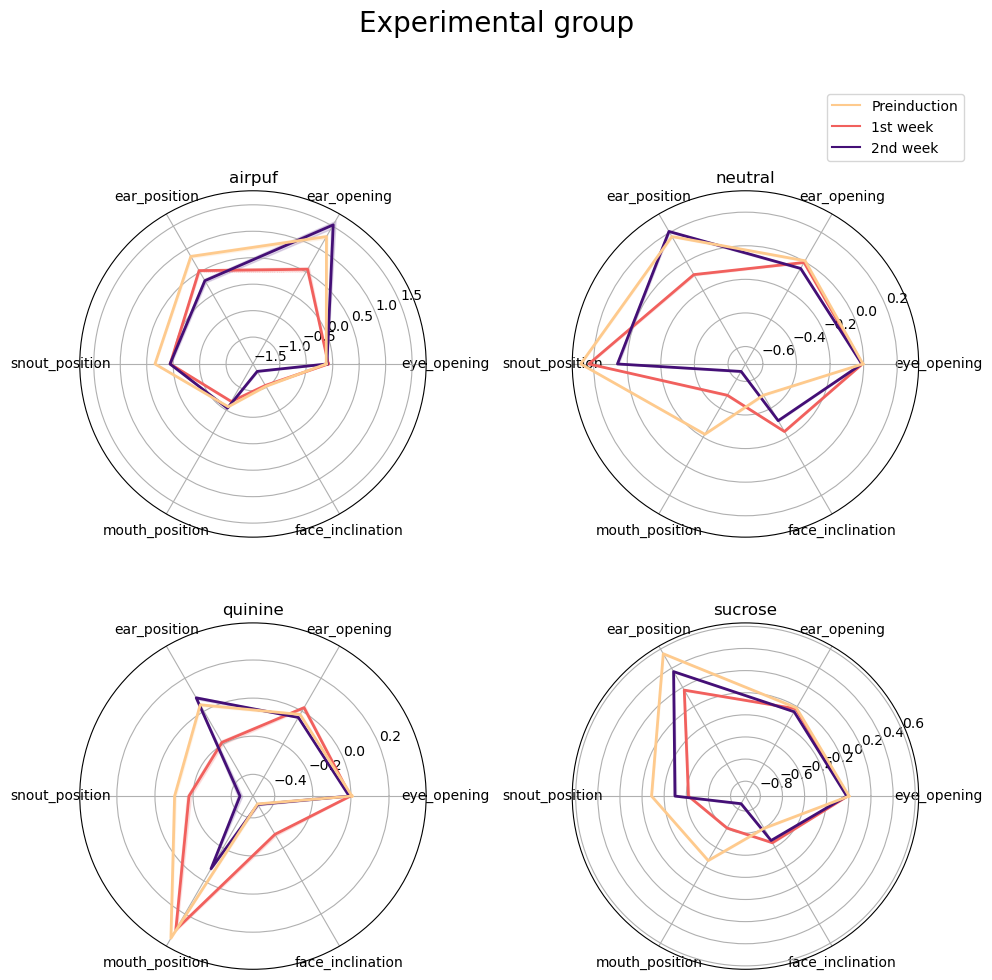

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import math

labels = quant_cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

stimuli = sorted(fq_df["stimuli"].unique())
groups = sorted(fq_df["phase"].unique())

# Explicit colors per group
group_colors = {
    "Preinduction": "#feca8d",
    "1st week": "#f1605d",
    "2nd week": "#440f76",
}

cols = 2
rows = math.ceil(len(stimuli) / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 5, rows * 5),
    subplot_kw=dict(polar=True)
)

axes = axes.flatten()

for ax, stim in zip(axes, stimuli):

    stim_df = fq_df[(fq_df["stimuli"] == stim) & (fq_df["group"] == 'TDP43')]

    stim_mean = stim_df.groupby("phase")[quant_cols].mean()
    stim_sem  = stim_df.groupby("phase")[quant_cols].sem()

    for group in groups:
        if group not in stim_mean.index:
            continue

        values = stim_mean.loc[group].tolist()
        values += values[:1]

        sem = stim_sem.loc[group].tolist()
        sem += sem[:1]

        lower = np.array(values) - np.array(sem)
        upper = np.array(values) + np.array(sem)

        color = group_colors.get(group, "gray")

        ax.plot(angles, values, linewidth=2, label=group, color=color)
        ax.fill_between(angles, lower, upper, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(stim)

# Hide unused axes
for ax in axes[len(stimuli):]:
    ax.set_visible(False)

# Global legend with correct colors
handles = []
labels_legend = []

for group in groups:
    color = group_colors.get(group, "gray")
    h, = axes[0].plot([], [], label=group, color=color)
    handles.append(h)
    labels_legend.append(group)

plt.suptitle("Experimental group", fontsize=20, y=1)


# Source - https://stackoverflow.com/a/46160465
# Posted by Ian Hincks
# Retrieved 2026-06-24, License - CC BY-SA 3.0

legend_order = ["Preinduction", "1st week", "2nd week"]  # your desired order

handles = []
labels_legend = []

for group in legend_order:
    color = group_colors.get(group, "gray")
    h, = axes[0].plot([], [], label=group, color=color)
    handles.append(h)
    labels_legend.append(group)

axes[1].legend(
    handles,
    labels_legend,
    loc="upper right",
    bbox_to_anchor=(1.15, 1.3)
)


plt.tight_layout()
plt.savefig("exp_group.svg")
plt.show()


ValueError: The palette dictionary is missing keys: {'WT', 'TDP43'}

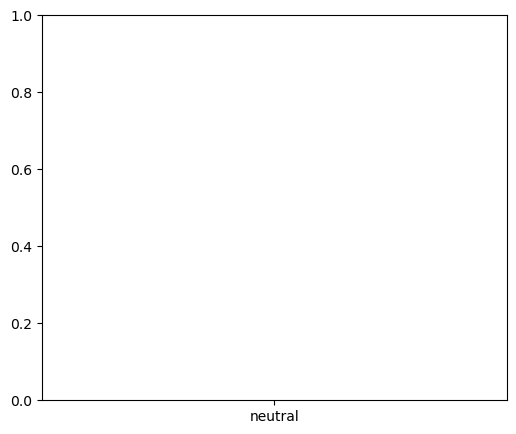

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

fq_df_filter

for metric in quant_cols:
    plt.figure(figsize=(6, 5))

    ax = sns.boxplot(
        data=fq_df_filter,
        x="stimuli",
        y=metric,
        hue="group",
        palette={"ill": "tab:red", "control": "tab:blue"}
    )

    # Build only valid pairs
    valid_pairs = []
    for stim in fq_df_filter["stimuli"].unique():
        groups_present = fq_df_filter[fq_df_filter["stimuli"] == stim]["group"].unique()

        if "ill" in groups_present and "control" in groups_present:
            valid_pairs.append(
                ((stim, "ill"), (stim, "control"))
            )

    # Only annotate if at least one valid pair exists
    if valid_pairs:
        annot = Annotator(
            ax,
            valid_pairs,
            data=fq_df_filter,
            x="stimuli",
            y=metric,
            hue="group"
        )

        annot.configure(test="t-test_ind", text_format="star", loc="outside")
        annot.apply_and_annotate()

    plt.title(f"{metric} — Group Comparison per Stimulus")
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Extract only the quantitative columns
X = fq_df_filter[quant_cols].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

# Add PCA results back to dataframe
fq_df_filter["PC1"] = pcs[:, 0]
fq_df_filter["PC2"] = pcs[:, 1]

# Plot
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=fq_df_filter,
    x="PC1",
    y="PC2",
    hue="stimuli",
    palette="Set2",
    alpha=0.8,
    s=60
)

plt.title("PCA of Face Quant Metrics (colored by stimulus)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
plt.show()
